## Topologia

Luxemburgo

In [40]:
positions = {0: (5000, 6000), 1: (2884, 6739), 2: (8081, 4302), 3: (8881, 4995), 4: (8956, 2900),
        5: (9693, 4040), 6: (4351, 6749), 7: (5341, 7590), 8: (6053, 8420), 9: (6230, 5831),
        10: (6446, 6969), 11: (6776, 7725), 12: (6785, 5631), 13: (7000, 8517), 14: (7034, 7203),
        15: (7041, 6100), 16: (7019, 3541), 17: (7295, 7026), 18: (7234, 5147), 19: (7336, 5733),
        20: (7477, 6206), 21: (7467, 5394), 22: (7605, 8238), 23: (7551, 5914), 24: (8266, 7723),
        25: (8403, 6861), 26: (9639, 7772), 27: (9868, 9199), 28: (10138, 9166), 29: (10433, 9612),
        30: (10652, 9036), 31: (1690, 8623), 32: (8839, 4462), 33: (1492, 7139), 34: (4500, 5500)}

topology = [(0, 34), (14, 17), (25, 24), (8, 13), (8, 22), (14, 10), (14, 11), (28, 27), (28, 29),
        (28, 30), (2, 3), (2, 32), (5, 4), (9, 12), (23, 15), (23, 19), (23, 20), (18, 21), (6, 7),
        (2, 16), (25, 26), (33, 1), (33, 31), (34, 9), (9, 18), (18, 2), (2, 5), (5, 23), (23, 25),
        (25, 28), (28, 14), (14, 8), (8, 6), (6, 33), (33, 34)]

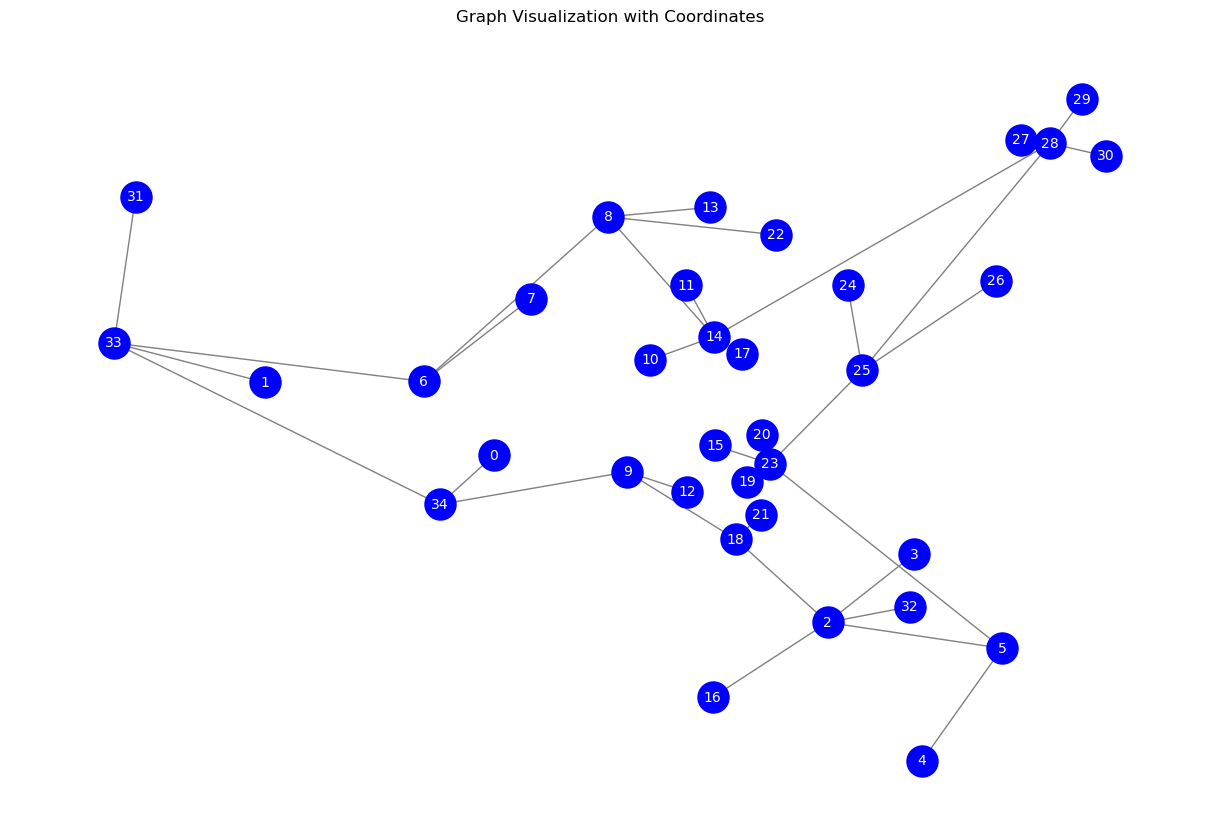

In [41]:
import matplotlib.pyplot as plt
import networkx as nx

# Create the graph
G = nx.Graph()
G.add_edges_from(topology)

# Scale the positions for visualization
scaled_positions = {node: (x / 1000, y / 1000) for node, (x, y) in positions.items()}

# Draw the graph
plt.figure(figsize=(12, 8))
nx.draw(
    G, 
    pos=scaled_positions, 
    with_labels=True, 
    node_size=500, 
    font_size=10, 
    font_color='white', 
    node_color='blue',
    edge_color='gray'
)
plt.title("Graph Visualization with Coordinates")
plt.show()

## Dados da simulação

In [60]:
import pandas as pd
# Da simulação especificamente
simulation_cpu = f"C:/Users/rodri/OneDrive/Documentos/GitHub/multi-user-sfc/results/results_cpu/alg_goku_s_50_p_50_sfc_on/202412222207281922683111.csv"
simulation_cache = f"C:/Users/rodri/OneDrive/Documentos/GitHub/multi-user-sfc/results/results_cache/alg_goku_s_50_p_50_sfc_on/202412222207281922683111.csv"

data_cpu = pd.read_csv(simulation_cpu)
data_cache = pd.read_csv(simulation_cache)

In [61]:
# Remove a coluna de timestamp
data_cpu.drop(columns='timestamp', inplace=True)
data_cache.drop(columns='timestamp', inplace=True)

# Remove a coluna de timestamp e redefine o índice
data_cpu.reset_index(drop=True, inplace=True)
data_cache.reset_index(drop=True, inplace=True)

# Agora os índices de data_cpu e data_cache serão 0, 1, 2, ...
print(data_cpu.head())  # Exibe as primeiras linhas para verificar
print(data_cache.head())  # Exibe as primeiras linhas para verificar


      2     5    6    8    9   14    18   23   25   28   33   34
0  10.0   0.0  0.0  0.0  0.0  0.0  0.00  0.0  0.0  0.0  0.0  0.0
1  31.0   0.0  0.0  0.0  0.0  0.0  0.00  0.0  0.0  0.0  0.0  0.0
2  31.0   0.0  0.0  0.0  0.0  0.0  1.67  0.0  0.0  0.0  0.0  0.0
3  31.0  21.0  0.0  0.0  0.0  0.0  1.67  0.0  0.0  0.0  0.0  0.0
4  31.0  21.0  0.0  0.0  0.0  0.0  3.33  0.0  0.0  0.0  0.0  0.0
      2    5    6    8    9   14   18   23   25   28   33   34
0  33.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
1  33.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2  33.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
3  33.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
4  33.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0


In [67]:
# Seleciona a primeira linha válida (ajuste conforme necessário)
selected_timestamp = data_cpu.index[200]

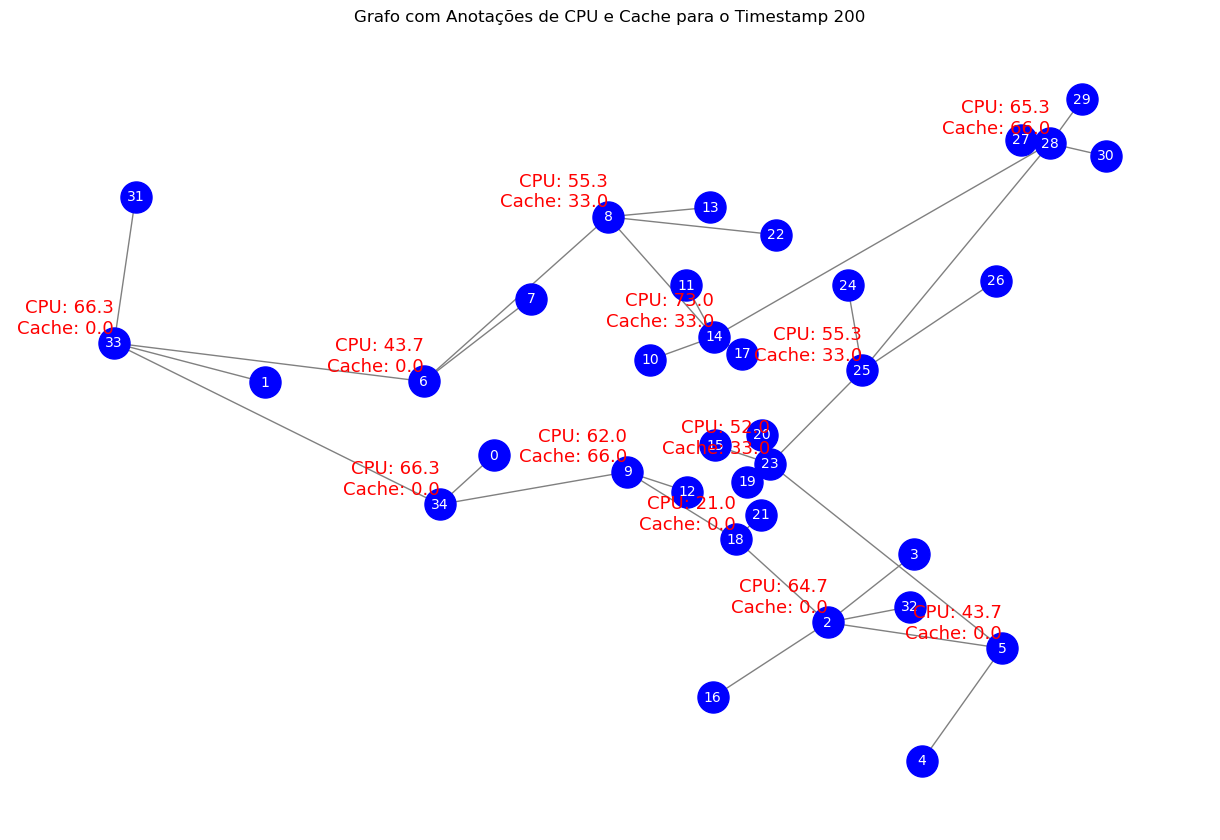

In [ ]:
cpu_data = data_cpu.loc[selected_timestamp]
cache_data = data_cache.loc[selected_timestamp]

# Define os rótulos para os nós (CPU e Cache com valores válidos)
labels = {
    node: f"CPU: {cpu_data[str(node)]:.1f}\nCache: {cache_data[str(node)]:.1f}" 
    for node in G.nodes 
    if str(node) in cpu_data.index and pd.notna(cpu_data[str(node)]) 
    and str(node) in cache_data.index and pd.notna(cache_data[str(node)])
}

# Visualização do grafo
plt.figure(figsize=(12, 8))
nx.draw(
    G, 
    pos=scaled_positions, 
    with_labels=True, 
    node_size=500, 
    font_size=10, 
    font_color='white', 
    node_color='blue',
    edge_color='gray'
)

# Adiciona as anotações e marca os nós com valores `None` com um 'X'
for node, (x, y) in scaled_positions.items():
    if node in labels:
        plt.text(x, y + 0.1, labels[node], fontsize=13, ha='right', color='red')
    elif (str(node) in cpu_data.index and pd.isna(cpu_data[str(node)])) or \
         (str(node) in cache_data.index and pd.isna(cache_data[str(node)])):
        plt.text(x, y, 'X', fontsize=12, ha='center', va='center', color='yellow')

#plt.title(f"Grafo com Anotações de CPU e Cache para o Timestamp {selected_timestamp}")
plt.show()

## Criando o vídeo

In [84]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import cv2
import os

# Configurações
output_video = "graph_animation.mp4"  # Nome do arquivo de saída
frame_duration = 1000  # Duração de cada frame em milissegundos
fps = 1  # Frames por segundo (calculado pelo inverso da duração do frame)

# Da simulação especificamente
simulation_cpu = f"C:/Users/rodri/OneDrive/Documentos/GitHub/multi-user-sfc/results/results_cpu/alg_goku_s_50_p_50_sfc_on/202412230041112181917681.csv"
simulation_cache = f"C:/Users/rodri/OneDrive/Documentos/GitHub/multi-user-sfc/results/results_cache/alg_goku_s_50_p_50_sfc_on/202412230041112181917681.csv"


data_cpu = pd.read_csv(simulation_cpu)
data_cache = pd.read_csv(simulation_cache)

data_cpu.drop(columns='timestamp', inplace=True)
data_cache.drop(columns='timestamp', inplace=True)

# Remove a coluna de timestamp e redefine o índice
data_cpu.reset_index(drop=True, inplace=True)
data_cache.reset_index(drop=True, inplace=True)


# Inicializa o grafo
G = nx.Graph()
G.add_edges_from(topology)

# Escala as posições para visualização
scaled_positions = {node: (x / 1000, y / 1000) for node, (x, y) in positions.items()}

# Pasta temporária para salvar os frames
frames_folder = "frames"
os.makedirs(frames_folder, exist_ok=True)

# Gera gráficos para cada timestamp
frame_paths = []
for i, timestamp in enumerate(data_cpu.index):
    cpu_data = data_cpu.loc[timestamp]
    cache_data = data_cache.loc[timestamp]

    # Define os rótulos para os nós (CPU e Cache com valores válidos)
    labels = {
        node: f"CPU: {cpu_data[str(node)]:.1f}\nCache: {cache_data[str(node)]:.1f}" 
        for node in G.nodes 
        if str(node) in cpu_data.index and pd.notna(cpu_data[str(node)]) 
        and str(node) in cache_data.index and pd.notna(cache_data[str(node)])
    }

    # Visualização do grafo
    plt.figure(figsize=(12, 8))
    nx.draw(
        G, 
        pos=scaled_positions, 
        with_labels=True, 
        node_size=500, 
        font_size=10, 
        font_color='white', 
        node_color='blue',
        edge_color='gray'
    )

    # Adiciona as anotações e marca os nós com valores `None` com um 'X'
    for node, (x, y) in scaled_positions.items():
        if node in labels:
            plt.text(x, y + 0.1, labels[node], fontsize=13, ha='right', color='red')
        elif (str(node) in cpu_data.index and pd.isna(cpu_data[str(node)])) or \
            (str(node) in cache_data.index and pd.isna(cache_data[str(node)])):
            plt.text(x, y, 'X', fontsize=12, ha='center', va='center', color='yellow')

    #plt.title(f"Grafo com Anotações de CPU e Cache para o Timestamp {selected_timestamp}")
    # Salva o frame temporário
    frame_path = os.path.join(frames_folder, f"frame_{i}.png")
    plt.savefig(frame_path)
    frame_paths.append(frame_path)
    plt.close()

# Criação do vídeo com OpenCV
height, width = None, None
video_writer = None

for frame_path in frame_paths:
    frame = cv2.imread(frame_path)
    if video_writer is None:
        height, width, _ = frame.shape
        video_writer = cv2.VideoWriter(output_video, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))
    video_writer.write(frame)

# Libera os recursos
video_writer.release()

# Remove os frames temporários
for frame_path in frame_paths:
    os.remove(frame_path)

os.rmdir(frames_folder)

print(f"Vídeo criado com sucesso: {output_video}")

Vídeo criado com sucesso: graph_animation.mp4
